In [13]:

import shap
import os

from src.explainability import shap_summary_global
from src.data_processing import load_processed_data
from pathlib import Path
import joblib
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


from src.explainability import lasso_comparison_benchmark_vs_optuna


In [14]:
# Wczytaj X_test_fs
X_test_fs = pd.read_csv("../data/processed/X_test_fs.csv")

# Kolumny X_test_fs = selected features
selected_features = X_test_fs.columns.tolist()

print(f"Selected features ({len(selected_features)}):")
for i, feat in enumerate(selected_features, 1):
    print(f"  {i}. {feat}")

# Zapisz
output_path = Path("../data/processed/selected_features_lasso.csv")
output_path.parent.mkdir(parents=True, exist_ok=True)

pd.DataFrame({'feature': selected_features}).to_csv(output_path, index=False)
print(f"\n✓ Saved to: {output_path}")

Selected features (17):
  1. apparent_temperature
  2. relative_humidity
  3. hour
  4. day_of_week
  5. hour_sin
  6. hour_cos
  7. is_morning
  8. is_evening
  9. consumption_lag_168h
  10. consumption_rolling_std_3h
  11. consumption_per_sqm
  12. consumption_per_person
  13. pca_1
  14. pca_2
  15. pca_3
  16. pca_5
  17. built_year_1999.0

✓ Saved to: ..\data\processed\selected_features_lasso.csv


In [15]:
# Bieżący katalog roboczy (working directory)
current_dir = os.getcwd()

# Ścieżka do folderu nadrzędnego
parent_dir = os.path.dirname(current_dir)

# Ścieżka do folderu "data" w folderze nadrzędnym
data_path = os.path.join(parent_dir, 'data')

print(data_path)

C:\Users\aiszk\PycharmProjects\PythonProject\data


## SHAP

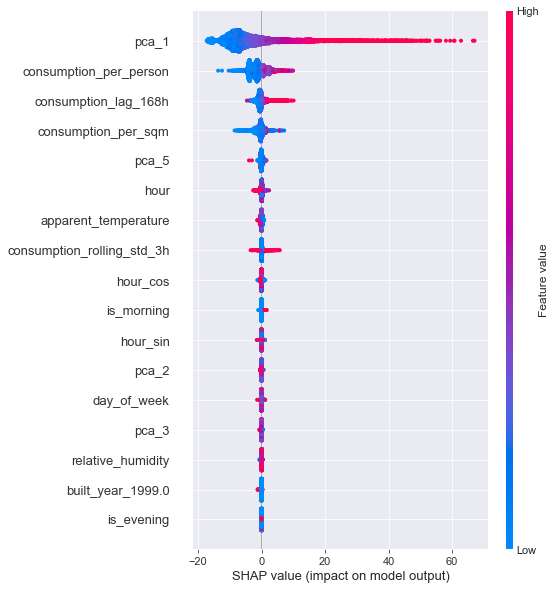

In [16]:
best_xgb = joblib.load("../models/best_xgb_optuna.joblib")
X_test_fs = pd.read_csv(f"{data_path}/processed/X_test_fs.csv")
shap_summary_global(best_xgb, X_test_fs.sample(10000))


Najważniejsze cechy <br>
Największy wpływ mają: pca_1, consumption_per_person, consumption_lag_168h i consumption_per_sqm – to one w praktyce „niosą” model.

Kolejne cechy (pca_5, hour, apparent_temperature, consumption_rolling_std_3h itd.) mają już znacznie mniejszy, ale nadal istotny wpływ; reszta na dole listy wpływa marginalnie (SHAP ~ 0).

Kierunek wpływu (kolor vs. położenie)
Kolor punktu to wartość cechy (niebieski – nisko, różowy – wysoko), położenie na osi X to wpływ na wynik (SHAP dodatni → większa przewidywana konsumpcja, ujemny → mniejsza).

Dla np. consumption_per_person widać, że wysokie wartości (różowe) są głównie po prawej stronie → zwiększają prognozowane zużycie, a niskie (niebieskie) po lewej → obniżają je; podobny wzór ma consumption_per_sqm i lag 168h.

Wnioski praktyczne
Model silnie opiera się na zagregowanej informacji z pca_1 (kombinacja Twoich wejściowych cech) oraz intuicyjnych zmiennych „na osobę”, „na m²” i opóźnionej konsumpcji, więc te feature’y są dobrze zaprojektowane.

Zmienne czasowe (hour, day_of_week, is_morning, is_evening, hour_sin/cos) oraz pogodowe (apparent_temperature, relative_humidity) mają zauważalny, ale wtórny wpływ – pomagają doprecyzować poziom zużycia, ale nie dominują nad historyczną konsumpcją i skalowaniem per osoba/m².

In [38]:
pca_com = pd.read_csv(f"{data_path}/processed/pca_components.csv")
pca_com

,feature,PC0,PC1,PC2,PC3,PC4,PC5
0,air_temperature,0.063944,0.419373,0.493721,0.268125,0.001914,-0.258430
1,week_of_year,-0.013278,-0.576085,0.267649,0.294313,0.019692,-0.087250
2,quarter,-0.013010,-0.574115,0.268895,0.291741,0.020225,-0.120727
3,consumption_lag_1h,0.445343,-0.024211,-0.025879,-0.004372,0.046064,0.009275
4,consumption_lag_24h,0.430014,-0.029907,-0.052112,0.006717,0.040387,0.002430
5,consumption_rolling_mean_3h,0.445867,-0.024278,-0.025965,-0.004341,0.045922,0.009227
6,consumption_rolling_mean_6h,0.446928,-0.023643,-0.024218,-0.004339,0.046014,0.008766
7,consumption_rolling_mean_24h,0.447076,-0.024436,-0.029507,-0.000846,0.044655,0.005473
8,humidity_level,-0.062347,-0.194627,-0.633623,0.293359,0.024617,0.316955
9,wind_speed_squared,0.022995,0.030914,0.436582,-0.016595,-0.046173,0.897069


Z tabeli ładunków PCA widać, że w PC0 wysokie wartości mają m.in.

week_of_year, quarter (silne współczynniki ujemne w PC0)

różne rolling/lag consumption (consumption_lag_1h, 24h, rolling_mean_3h/6h/24h) – tu współczynniki dodatnie w PC1

To oznacza, że:

pca_1 jest w dużej mierze kombinacją historii zużycia, skorygowaną o sezonowość (week_of_year, quarter).

In [17]:
explainer = shap.TreeExplainer(best_xgb)
shap_values = explainer.shap_values(X_test_fs)

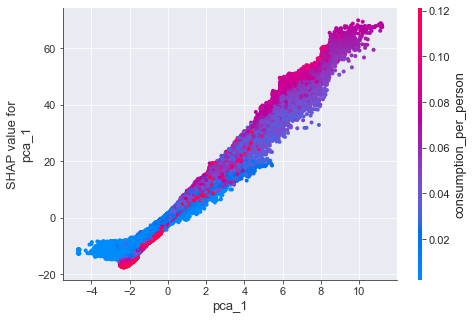

In [18]:
# podstawowy dependence plot
shap.dependence_plot(
    "pca_1",                 # cecha główna (oś X)
    shap_values,             # SHAP values
    X_test_fs,               # dane
    interaction_index="consumption_per_person"  # kolor = ta cecha
)


### WNIOSKI

Kształt zależności pca_1 → predykcja
Oś X: wartość pca_1.

Oś Y: SHAP dla pca_1 (wpływ na prognozowane zużycie).

Wykres jest prawie rosnącą, gładką krzywą: przy niskim pca_1 SHAP jest ujemny (cecha obniża prognozę), a od okolic 0 w górę SHAP szybko rośnie aż do +60–70, mocno podbijając zużycie.

POROWANIE: GB BENCHMARK vs XGBoost OPTUNA
XGBoost Optuna loaded!

KSZTALTY DANYCH:
GB Benchmark: (786246, 70) cech
XGB Optuna:   (786246, 17) cech


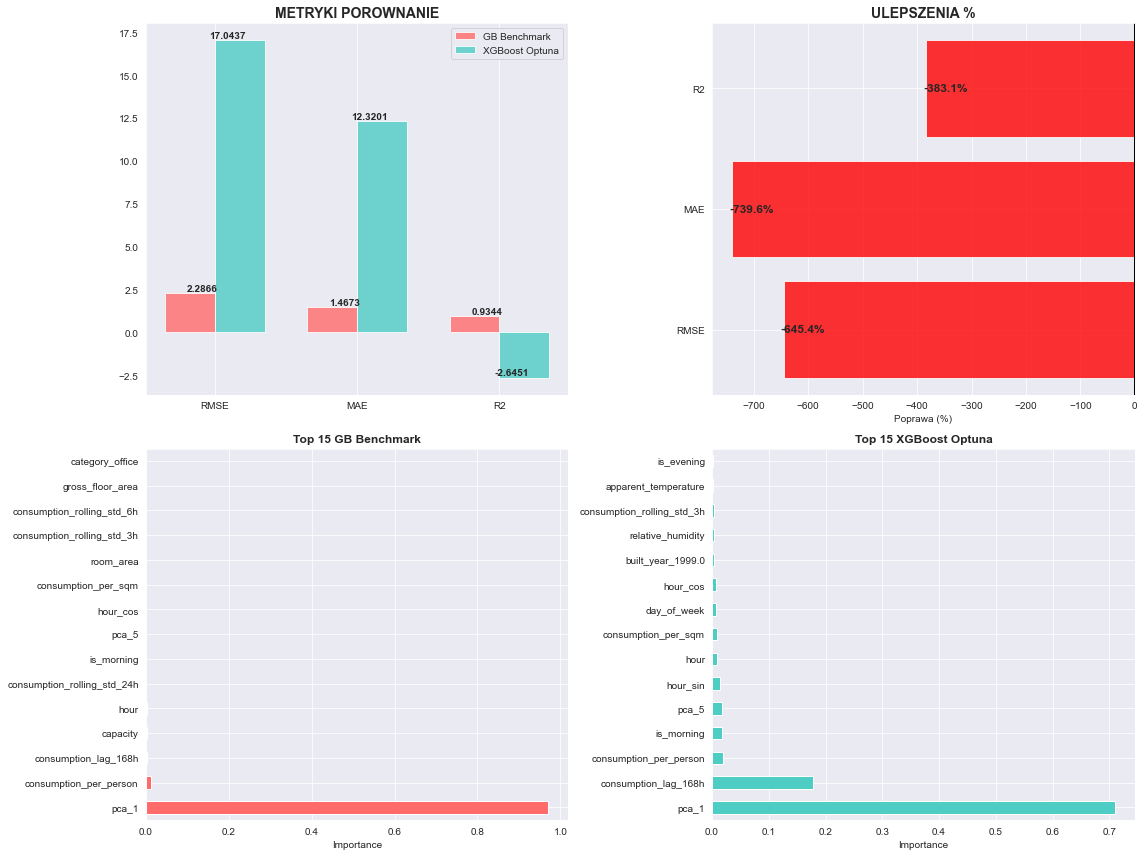


FINALNE POROWANIE GB vs XGB

GB BENCHMARK (70 cech):
   RMSE: 2.2866 | MAE: 1.4673 | R2: 0.9344

XGBoost OPTUNA (17 cech):
   RMSE: 17.0437 | MAE: 12.3201 | R2: -2.6451

ULEPSZENIA:
   RMSE: -645.4%
   MAE:  -739.6%
   R2:   -383.1%
   Cechy: 17 vs 48 (-64.6%)


In [25]:
print("POROWANIE: GB BENCHMARK vs XGBoost OPTUNA")
print("="*60)

# ============ WCZYTAJ MODELE ============
gb_benchmark = joblib.load("../models/gb_benchmark.joblib")

try:
    xgb_optuna = joblib.load("../models/best_xgb_optuna.joblib")
    print("XGBoost Optuna loaded!")
except:
    print("Brak best_xgb_optuna.joblib!")
    print("W 05-optymalizacja zapisz: joblib.dump(best_xgb_model, '../models/best_xgb_optuna.joblib')")
    # exit()  # usuń żeby kontynuować

# ============ WCZYTAJ DANE ============
X_test_benchmark = joblib.load("../data/processed/X_test_benchmark.joblib")
y_test_benchmark = joblib.load("../data/processed/y_test_benchmark.joblib")

X_test_fs = pd.read_csv("../data/processed/X_test_fs.csv")
y_test_fs = y_test_benchmark.iloc[:len(X_test_fs)]

print(f"\nKSZTALTY DANYCH:")
print(f"GB Benchmark: {X_test_benchmark.shape} cech")
print(f"XGB Optuna:   {X_test_fs.shape} cech")

# ============ METRYKI GB BENCHMARK ============
y_pred_gb = gb_benchmark.predict(X_test_benchmark)
gb_rmse = mean_squared_error(y_test_benchmark, y_pred_gb, squared=False)
gb_mae = mean_absolute_error(y_test_benchmark, y_pred_gb)
gb_r2 = r2_score(y_test_benchmark, y_pred_gb)

# ============ METRYKI XGB OPTUNA ============
y_pred_xgb = xgb_optuna.predict(X_test_fs)
xgb_rmse = mean_squared_error(y_test_fs, y_pred_xgb, squared=False)
xgb_mae = mean_absolute_error(y_test_fs, y_pred_xgb)
xgb_r2 = r2_score(y_test_fs, y_pred_xgb)

# ============ WIZUALIZACJA ============
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. METRYKI
metrics = ['RMSE', 'MAE', 'R2']
gb_vals = [gb_rmse, gb_mae, gb_r2]
xgb_vals = [xgb_rmse, xgb_mae, xgb_r2]

x = np.arange(len(metrics))
width = 0.35

axes[0,0].bar(x - width/2, gb_vals, width, label='GB Benchmark', color='#FF6B6B', alpha=0.8)
axes[0,0].bar(x + width/2, xgb_vals, width, label='XGBoost Optuna', color='#4ECDC4', alpha=0.8)
axes[0,0].set_title('METRYKI POROWNANIE', fontweight='bold', fontsize=14)
axes[0,0].set_xticks(x)
axes[0,0].set_xticklabels(metrics)
axes[0,0].legend()
axes[0,0].grid(axis='y', alpha=0.3)

# Wartości na słupkach
for i, vals in enumerate([gb_vals, xgb_vals]):
    for j, val in enumerate(vals):
        axes[0,0].text(j + (i-0.5)*width/2, val + 0.01*(i*2-1), f'{val:.4f}',
                      ha='center', va='bottom', fontweight='bold')

# 2. ULEPSZENIA %
rmse_imp = ((gb_rmse - xgb_rmse) / gb_rmse) * 100
mae_imp = ((gb_mae - xgb_mae) / gb_mae) * 100
r2_imp = ((xgb_r2 - gb_r2) / gb_r2) * 100

imps = [rmse_imp, mae_imp, r2_imp]
colors = ['green' if x > 0 else 'red' for x in imps]
axes[0,1].barh(metrics, imps, color=colors, alpha=0.8)
axes[0,1].axvline(0, color='black', linewidth=2)
axes[0,1].set_title('ULEPSZENIA %', fontweight='bold', fontsize=14)
axes[0,1].set_xlabel('Poprawa (%)')

for i, imp in enumerate(imps):
    axes[0,1].text(imp + (5 if imp > 0 else -5), i, f'{imp:+.1f}%',
                  va='center', fontweight='bold', fontsize=12)

# 3. FEATURE IMPORTANCE GB
importances_gb = pd.Series(gb_benchmark.feature_importances_,
                         index=X_test_benchmark.columns).nlargest(15)
importances_gb.plot(kind='barh', ax=axes[1,0], color='#FF6B6B')
axes[1,0].set_title('Top 15 GB Benchmark', fontweight='bold')
axes[1,0].set_xlabel('Importance')

# 4. FEATURE IMPORTANCE XGB
importances_xgb = pd.Series(xgb_optuna.feature_importances_,
                          index=X_test_fs.columns).nlargest(15)
importances_xgb.plot(kind='barh', ax=axes[1,1], color='#4ECDC4')
axes[1,1].set_title('Top 15 XGBoost Optuna', fontweight='bold')
axes[1,1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

# ============ PODSUMOWANIE ============
print("\n" + "="*80)
print("FINALNE POROWANIE GB vs XGB")
print("="*80)
print(f"\nGB BENCHMARK (70 cech):")
print(f"   RMSE: {gb_rmse:.4f} | MAE: {gb_mae:.4f} | R2: {gb_r2:.4f}")
print(f"\nXGBoost OPTUNA ({len(X_test_fs.columns)} cech):")
print(f"   RMSE: {xgb_rmse:.4f} | MAE: {xgb_mae:.4f} | R2: {xgb_r2:.4f}")
print(f"\nULEPSZENIA:")
print(f"   RMSE: {rmse_imp:+.1f}%")
print(f"   MAE:  {mae_imp:+.1f}%")
print(f"   R2:   {r2_imp:+.1f}%")
print(f"   Cechy: {len(X_test_fs.columns)} vs 48 (-{100*(1-len(X_test_fs.columns)/48):.1f}%)")
print("="*80)



In [20]:
# 1. Wczytaj modele
gb_benchmark = joblib.load("../models/gb_benchmark.joblib")
xgb_optuna = joblib.load("../models/best_xgb_optuna.joblib")

# 2. Wczytaj X_test i y_test z benchmarku
X_test_benchmark = joblib.load("../data/processed/X_test_benchmark.joblib")
y_test = joblib.load("../data/processed/y_test_benchmark.joblib")  # ← to Twój target

# 3. X_test_fs (te same wiersze, tylko 17 kolumn)
X_test_fs = pd.read_csv("../data/processed/X_test_fs.csv")

print(X_test_benchmark.shape, X_test_fs.shape, y_test.shape)

# 4. Metryki GB (70 cech)
y_pred_gb = gb_benchmark.predict(X_test_benchmark)
gb_rmse = mean_squared_error(y_test, y_pred_gb, squared=False)
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_r2 = r2_score(y_test, y_pred_gb)

# 5. Metryki XGB (17 cech, ten sam y_test)
y_pred_xgb = xgb_optuna.predict(X_test_fs)
xgb_rmse = mean_squared_error(y_test, y_pred_xgb, squared=False)
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("GB benchmark:", gb_rmse, gb_mae, gb_r2)
print("XGB optuna:  ", xgb_rmse, xgb_mae, xgb_r2)

(786246, 70) (786246, 17) (786246,)
GB benchmark: 2.286615995791676 1.4672899919439668 0.934390596150129
XGB optuna:   17.043666436316844 12.320064068679487 -2.64506828941612


In [21]:
y1 = joblib.load("../data/processed/y_test_benchmark.joblib")

y2 = joblib.load("../data/processed/y_test_fs_optuna.joblib")

In [22]:
print((y1.values == y2.values).all())
print(y1.head(), y2.head())


False
3144981    24.250
3144982    21.250
3144983    21.875
3144984    24.750
3144985    22.125
Name: consumption, dtype: float64 3144981    18.7500
3144982    12.8750
3144983     2.0625
3144984     9.0000
3144985     4.0000
Name: consumption, dtype: float64


In [23]:
X_test = joblib.load("../data/processed/X_test_benchmark.joblib")
y_test = joblib.load("../data/processed/y_test_benchmark.joblib")
X_test_fs = pd.read_csv("../data/processed/X_test_fs.csv")

In [24]:

gb_benchmark = joblib.load("../models/gb_benchmark.joblib")
xgb_optuna = joblib.load("../models/best_xgb_optuna.joblib")

# GB na pełnych 70 cechach
y_pred_gb = gb_benchmark.predict(X_test)
gb_rmse = mean_squared_error(y_test, y_pred_gb, squared=False)
gb_mae = mean_absolute_error(y_test, y_pred_gb)
gb_r2 = r2_score(y_test, y_pred_gb)

# XGB na 17 cechach (X_test_fs, ten sam y_test)
y_pred_xgb = xgb_optuna.predict(X_test_fs)
xgb_rmse = mean_squared_error(y_test, y_pred_xgb, squared=False)
xgb_mae = mean_absolute_error(y_test, y_pred_xgb)
xgb_r2 = r2_score(y_test, y_pred_xgb)

print("GB :", gb_rmse, gb_mae, gb_r2)
print("XGB:", xgb_rmse, xgb_mae, xgb_r2)


GB : 2.286615995791676 1.4672899919439668 0.934390596150129
XGB: 17.043666436316844 12.320064068679487 -2.64506828941612


## WNIOSKI KONCOWE I NASTEPNE KROKI

Gradient Boosting (70 cech): RMSE ≈ 2.29, MAE ≈ 1.47, R² ≈ 0.93: błąd jest mały względem typowych wartości celu, a R² blisko 1 oznacza, że większość wariancji celu jest wyjaśniona. <br>
XGBoost po tuningu działa wyraźnie źle.


Jesli dalej bysmy chceli pracowac na tym modelem to nastepne kroki wygladalayby tak:
1. Najpierw sanity‑check modelu (np uruchomienie XGB z domyslnymi paramaterami)
2. Weryfikacja przygotowanych cech
3. Przemyśl redukcję cech
    - Doprowadzic XGBoost z pełnymi (lub lekko oczyszczonymi) cechami do wyniku zbliżonego do GB, a dopiero potem ewentualnie robic agresywną selekcję (np. po SHAP / feature importance XGB).


